In [ ]:
import os
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi

plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [6]:
file_path = "기사제목_목데이터.xlsx"

df = pd.read_csv(r"C:\Users\Admin\Documents\GitHub\Ml_Baseball\dy_\프로야구_제목.csv", encoding="utf-8-sig")

print(df.shape)
display(df.head())
print(df.columns)

(330, 1)


,제목
0,"프로야구, 최소 경기 200만 관중 신기록"
1,‘뜨거운 프로야구’ 117경기 만에 200만 관중 달성…최단 기록
2,"프로야구, '역대 최소' 117G 만에 200만 관중 달성"
3,"김진태-정광열 ""'춘천 연고' 프로야구 1군 구단 창단·유치"""
4,"김진태, 프로야구단 유치하겠다…""서대문 의원 우상호, TV 토론 좀 하자..."


Index(['제목'], dtype='str')


In [8]:
# 기사 제목 자동찾기
candidate_cols = ["제목", "기사제목", "뉴스제목", "title", "headline", "subject"]

title_col = None

for col in df.columns:
    if str(col).strip() in candidate_cols:
        title_col = col
        break

if title_col is None:
    object_cols = df.select_dtypes(include="object").columns
    if len(object_cols) > 0:
        title_col = object_cols[0]
    else:
        raise ValueError("기사 제목으로 사용할 수 있는 문자형 컬럼을 찾지 못했습니다.")

print("사용할 제목 컬럼:", title_col)

사용할 제목 컬럼: 제목


In [ ]:
# 제목 데이터 정리
titles = (
    df[title_col]
    .dropna()
    .astype(str)
    .str.strip()
)

titles = titles[titles != ""]
titles = titles.drop_duplicates()

print("사용할 기사 제목 개수:", len(titles))
display(titles.head())

사용할 기사 제목 개수: 330


0                        프로야구, 최소 경기 200만 관중 신기록
1           ‘뜨거운 프로야구’ 117경기 만에 200만 관중 달성…최단 기록
2               프로야구, '역대 최소' 117G 만에 200만 관중 달성
3             김진태-정광열 "'춘천 연고' 프로야구 1군 구단 창단·유치"
4    김진태, 프로야구단 유치하겠다…"서대문 의원 우상호, TV 토론 좀 하자...
Name: 제목, dtype: str

In [10]:
# 한글 텍스트 정제 함수
def clean_text(text):
    text = re.sub(r"\[[^\]]*\]", " ", text)
    text = re.sub(r"\([^)]*\)", " ", text)
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [16]:
# 형태소 분석으로 명사 추출
kiwi = Kiwi()

stopwords = {
    "기자", "뉴스", "기사", "보도", "단독", "속보", "관련", "이번", "오늘",
    "지난", "내일", "올해", "최근", "통해", "대해", "위해", "대한",
    "사진", "영상", "제공", "출처", "무단", "전재", "배포", "금지",
    "것", "수", "등", "및", "더", "중", "전", "후", "곳", "때",
    "한국", "서울", "프로", "야구", "경기", "관중", "최소"
}

def extract_keywords(text):
    text = clean_text(text)
    tokens = kiwi.tokenize(text)

    words = []
    for token in tokens:
        word = token.form
        tag = token.tag

        if tag in ["NNG", "NNP", "SL"]:
            if len(word) >= 2 and word not in stopwords:
                words.append(word)

    return words

In [17]:
# 전체 제목에서 단어 빈도 계산
all_words = []

for title in titles:
    all_words.extend(extract_keywords(title))

word_counts = Counter(all_words)

freq_df = pd.DataFrame(
    word_counts.items(),
    columns=["word", "count"]
).sort_values("count", ascending=False)

display(freq_df.head(30))

,word,count
60,LG,28
88,삼성,23
3,역대,22
133,SSG,20
9,창단,18
135,한화,18
76,KIA,17
84,KBO,16
147,투수,16
8,구단,16


c:\Users\Admin\Documents\GitHub\Ml_Baseball\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Documents\GitHub\Ml_Baseball\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Documents\GitHub\Ml_Baseball\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Documents\GitHub\Ml_Baseball\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Documents\GitHub\Ml_Baseball\.venv\Lib\site-packages\IPython\core\pylabtools.py:

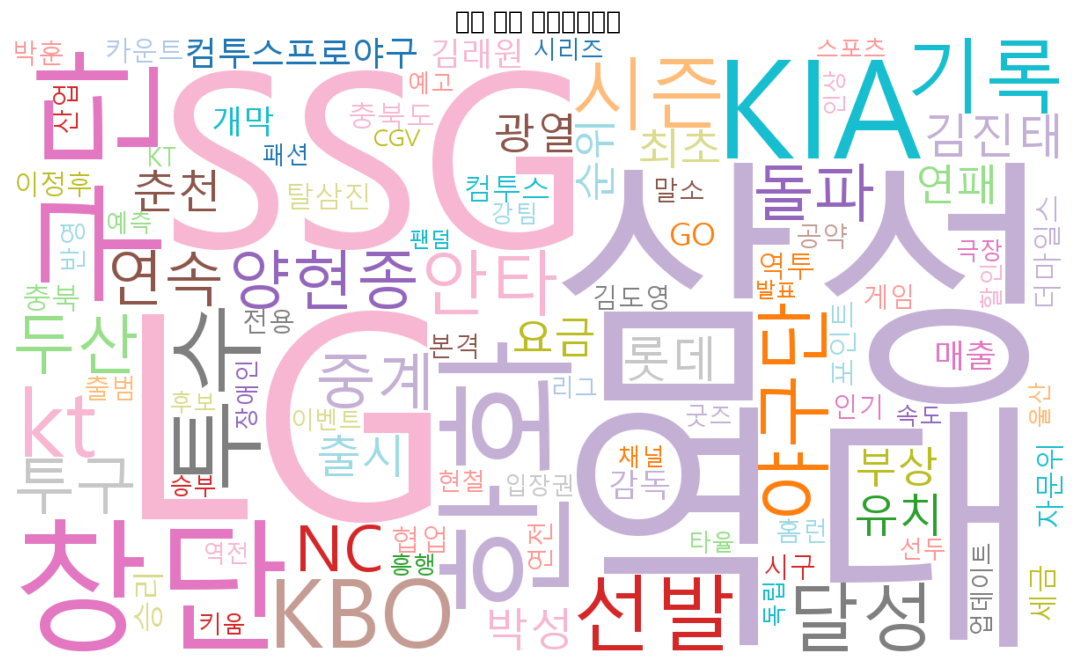

In [18]:
# 워드클라우드 생성
font_path = r"C:\Windows\Fonts\malgun.ttf"

if not os.path.exists(font_path):
    raise FileNotFoundError("한글 폰트 파일을 찾지 못했습니다. Windows 기본 폰트 malgun.ttf 경로를 확인하세요.")

wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    colormap="tab20"
).generate_from_frequencies(word_counts)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("기사 제목 워드클라우드", fontsize=18)
plt.show()